# Player Statistics

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
import warnings
from IPython.utils import io
from contextlib import contextmanager
from scipy.stats import uniform, loguniform
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif, chi2
from sklearn.svm import  SVC
from sklearn.compose import make_column_selector as selector
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_validate, train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

sns.set_theme()
%matplotlib inline

In [2]:
np.random.seed(0)

## (1) Read in Data


In [3]:
player_statistics = pd.read_csv(os.path.join("data", "api_player_stats.csv"))

## (2) Problem definition

In [4]:
player_statistics['pos'].value_counts()

pos
G    1244
F    1031
C     392
Name: count, dtype: int64

Since most observations are Forward and Guards, this represents an **imbalanced, multi-classs classification problem.** Additionally, False Positive's and False Negative's are equally importance (i.e. we want fair performance predicting across all classes).

As such, we will use appropriate metrics like:

* `balanced_accuracy`,
* `f1_macro`

## (3) Feature Selection

### Preparation of dataset

In [5]:
# separate data
target_name = "pos"
target = player_statistics[target_name]
data = player_statistics.drop(columns=[target_name, "player"])

# retrieve column types
numerical_columns_selector = selector(dtype_exclude=object)
numerical_columns = numerical_columns_selector(data)

# define transformers
numerical_preprocessor = StandardScaler()

# define column transformer
preprocessor = ColumnTransformer(
    [
        ("numerical_preprocessing", numerical_preprocessor, numerical_columns)
    ],
    remainder="passthrough"
)

In [6]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size = 0.25, stratify=target, random_state=42)

# Obtain feature names
feats = data.columns.tolist()

In [7]:
# KBest
def select_kbest_rankings(X_train, y_train, feats):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)
    select = SelectKBest(k=11)
    select.fit_transform(X_scaled, y_train)
    scores = [(i, score) for i, score in enumerate(select.scores_)]
    sorted_scores = sorted(scores, key=lambda tup: tup[1], reverse=True)
    sorted_scores_feats = [(feats[idx], score) for idx, score in sorted_scores]
    sorted_feats = [feats[i] for i, _ in sorted_scores]
    print("--------------------------------")
    print("KBest Feature Selection")
    print("--------------------------------")
    print("Features with scores:")
    print(sorted_scores_feats, '\n')
    print("Features in order of importance (descending):")
    print(sorted_feats)
    print("--------------------------------")

# Mutual Information Gain
def mutualinfo_rankings(X_train, y_train, feats):
    importances = mutual_info_classif(X_train, y_train)
    df_test = pd.DataFrame({"features": feats, "importances": importances})
    df_sorted = df_test.sort_values('importances', ascending= False)
    print("Mutual Information Gain Feature Selection")
    print("--------------------------------")
    print("Features with scores:")
    print(list(zip(df_sorted.features.to_list(), df_sorted.importances.to_list())), '\n')
    print("Features in order of importance (descending):")
    print(df_sorted.features.to_list())
    print("--------------------------------")

def chi2_rankings(X_train, y_train, feats):
    # Drop 4 negative records
    mask = (X_train >= 0).all(axis=1)
    X_train_clean = X_train[mask]
    y_train_clean = y_train[mask]
    # Run chi2 test
    select = SelectKBest(score_func=chi2, k='all')
    select.fit(X_train_clean, y_train_clean)
    scores = [(feats[i], score) for i, score in enumerate(select.scores_)]
    sorted_scores = sorted(scores, key=lambda x: x[1], reverse=True)
    print("Chi2 Feature Selection")
    print("--------------------------------")
    print("Features with scores:")
    print(sorted_scores, '\n')
    print("Features in order of importance (descending):")
    print([f for f, _ in sorted_scores])
    print("--------------------------------")

select_kbest_rankings(X_train, y_train, feats)
mutualinfo_rankings(X_train, y_train, feats)
chi2_rankings(X_train, y_train, feats)

--------------------------------
KBest Feature Selection
--------------------------------
Features with scores:
[('BLK', 488.4256934648683), ('REB', 380.88415053327026), ('AST_TO', 209.1506840487035), ('AST', 127.77701512669897), ('STOCKS', 74.90272858428928), ('STL', 54.66096308233116), ('TOV', 13.587915117179291), ('FIC', 5.913780889426732), ('PTS', 5.191783427020241), ('year', 4.21021814315664), ('age', 2.059897739120669)] 

Features in order of importance (descending):
['BLK', 'REB', 'AST_TO', 'AST', 'STOCKS', 'STL', 'TOV', 'FIC', 'PTS', 'year', 'age']
--------------------------------
Mutual Information Gain Feature Selection
--------------------------------
Features with scores:
[('BLK', 0.19538341276374727), ('REB', 0.17567194296007949), ('AST_TO', 0.1577948897572361), ('AST', 0.09906349965242334), ('STOCKS', 0.03127798486920352), ('STL', 0.014955230015860854), ('FIC', 0.011822081835167086), ('age', 0.006696516360954474), ('PTS', 0.0064934343034475095), ('TOV', 0.0048132922954100

Get rid of age and year attributes (consistently part the 3 least important attributes).

In [8]:
# separate data
target_name = "pos"
target_response = player_statistics[target_name]

# encode target response
le = LabelEncoder()
target = le.fit_transform(target_response)

# separate data
data = player_statistics.drop(columns=[target_name, "player", "age", "year"])

# retrieve column types
numerical_columns_selector = selector(dtype_exclude=object)
numerical_columns = numerical_columns_selector(data)

# define transformers
numerical_preprocessor = StandardScaler()

# define column transformer
preprocessor = ColumnTransformer(
    [
        ("numerical_preprocessing", numerical_preprocessor, numerical_columns)
    ],
    remainder="passthrough"
)

## (4) Building ML Model

### Defining PlayerStatisticsModel class

In [9]:
class PlayerStatisticsModel:
    """
     This class enables easy the creation and evaluation of different models to predict a players position based
     on their statistics.
    """
    def __init__(self, model, preprocessor: ColumnTransformer, data: pd.DataFrame, target: pd.Series, cv: int):
        """
         Initialisation of PlayerStatisticsModel class.
        
         Inputs:
          - model: sklearn machine learning model class
          - preprocessor (ColumnTransformer): preprocessing steps
          - data: input features
          - target: input target
          - cv: number of cv folds to estimate generalisability of model
        """
        self.metrics = ["balanced_accuracy", "f1_macro"]  # metrics to evaluate/fit models
        self.cv = cv  # number of cv folds
        self.results = pd.DataFrame()   # dataframe to store performance results of models
        self.data = data
        self.target = target
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(data, target, test_size = 0.25, stratify=target, random_state=42)
        self.preprocessor = preprocessor
        self.model = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("model", model)
            ]
        )
    @contextmanager
    def _suppress_warnings_and_output(self):
        # save original warning environment variable
        original_warnings = os.environ.get("PYTHONWARNINGS", "")
        
        # suppress UserWarning and FutureWarning
        os.environ["PYTHONWARNINGS"] = "ignore::UserWarning, ignore::FutureWarning"
        warnings.filterwarnings("ignore", category=UserWarning)
        warnings.filterwarnings("ignore", category=FutureWarning)

        # capture all stdout/stderr output
        with io.capture_output() as captured:
            try:
                yield captured
            finally:
                # restore warnings environment and filters
                os.environ["PYTHONWARNINGS"] = original_warnings
                warnings.filterwarnings("default", category=UserWarning)
                warnings.filterwarnings("default", category=FutureWarning)
    def print_cv_results(self, dict_results:dict[tuple]):
        """
         Prints the mean and standard deviation cross-validation score for a specified metrics in a pretty format.
        
         Inputs:
          - dict_results (dict[tuple]): the mean & std results of a model on all evaluation metrics
        """
        for metric, value in dict_results.items():
            print(f"The mean cross-validation {metric} score is: "
            f"{value[0]:.3f} ± {value[1]:.3f}")
    def plot_fold_comparison(self, metric: str, fold_results: tuple[list[int]], label_names: tuple[str], colors: tuple[str]):
        """
         Plots a comparison of the model's evaluation metric (i.e. performance) on each individual cross-validation
         fold. If there are 4 cross-validation folds, a scatterplot with four dots will be plotted.
        
         Inputs:
          - metric (str): sklearn evaluation metric of choice
          - fold_results (tuple[list[int]]): tuple containing the fold results of each model
          - label_names (tuple[str]): names to give each to each model in the legend of plot
          - colors (tuple[str]): colors to give each model in the plot
        """
        # handle edge case: user passes in invalid metric to plot
        if metric not in self.metrics:
            raise Exception(f"Please pass in a valid metric: {self.metrics}")
        else:
            fig, ax = plt.subplots(figsize=(6, 5))
            # iterate through each model's fold_result, adding scatterplots
            for i in range(len(fold_results)):
                indicies = np.arange(len(fold_results[i][metric]))
                sns.scatterplot(x=indicies, y=fold_results[i][metric], color=f"tab:{colors[i]}", label=label_names[i], ax=ax)
            # plot axis settings
            ax.set_xlabel("Cross-validation iteration")
            ax.set_ylabel("Balanced Accuracy")
            ax.set_title(f"{self.cv}-Fold {metric}")
            ax.set_xticks(np.arange(0, self.cv))
            ax.set_ylim(0,1)
            ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    def _add_model_results(self, model_result: dict[list], model_name: str):
        """
         Anonymous function that concatenates the mean and standard deviation cross-validation score for all
         specified metrics of a model onto a pre-existing dataframe (self.results). This enables us to 
         quickly compare the cv-performance of models as we build them.

         Inputs:
          - model_result (dict[list]): dictionary containing the mean & std results for each model metric
          - model_name (str): name of the model that will exist as its index in the self.results df
        """   
        # Gets model results as df to append to self.results
        df = pd.DataFrame(model_result)
        # extract rows and add suffixes to column names, then combine
        mean_row = df.iloc[0].rename(lambda col: f"{col}_mean")
        std_row = df.iloc[1].rename(lambda col: f"{col}_std")
        flattened_series = pd.concat([mean_row, std_row])
        flattened_df = pd.DataFrame([flattened_series])
        # set the index to the model name
        flattened_df.index = [model_name]
        # if model already exists in results df, then replace. Otherwise, append.
        if model_name in list(self.results.index):
            self.results.loc[model_name] = flattened_df.iloc[0]
        else:
            self.results = pd.concat([self.results, flattened_df])
    def cv_score(self, model_name: str) -> tuple[dict[list], dict[list]]:
        """
         Runs cross-validation on the default model (i.e. without hyperparameter tuning), obtaining the 
         performance of the model.

         Inputs:
          - model_name (str): name of the model that will exist as its index in the self.results df
         
         Returns:
          - dict_scores_agg (dict[list]): dictionary containing the mean & std results for each model metric
          - dict_scores_folds (dict[list]): dictionary containing the model metric results for each fold
        """   
        # get CV scores for default model
        dict_scores_agg = dict()
        dict_scores_folds = dict()
        for metric in self.metrics:
            cv_results = cross_validate(self.model, data, target, cv=self.cv, scoring=metric)
            scoring = cv_results['test_score']
            dict_scores_agg[metric] = (scoring.mean(), scoring.std())
            dict_scores_folds[metric] = scoring
        self._add_model_results(dict_scores_agg, model_name)
        return dict_scores_agg, dict_scores_folds
    def grid_search_cv_score(self, model_name: str, param_grid: dict):
        """
         Fits a model with grid_search to tune its hyperparameters. Then performs nested cross-validation to
         obtain an estimate of the generalisability of the model & variance of this estimate.

         Inputs:
          - model_name (str): name of the model that will exist as its index in the self.results df
          - param_grid (dict): grid of hyperparameters to iterate through
         
         Returns:
          - dict_scores_agg (dict[list]): dictionary containing the mean & std results for each model metric
          - dict_scores_folds (dict[list]): dictionary containing the model metric results for each fold
          - best_model: sklearn model of best performing model after gridsearch hyperparameter tuning
        """
        with self._suppress_warnings_and_output():
            model_grid_search = GridSearchCV(self.model, param_grid=param_grid, n_jobs=-1, scoring=self.metrics, refit=self.metrics[0], verbose=1)
            # fit grid search on training data to extract best model
            model_grid_search.fit(self.X_train, self.y_train)
            best_model = model_grid_search.best_estimator_
            # get nested CV scores for best model
            dict_scores_agg = dict()
            dict_scores_folds = dict()
            # perform nested cv for each metric, storing results in dictionaries
            for metric in self.metrics:
                cv_results = cross_validate(model_grid_search, data, target, cv=self.cv, n_jobs=-1, scoring=metric)
                scoring = cv_results['test_score']
                dict_scores_agg[metric] = (scoring.mean(), scoring.std())
                dict_scores_folds[metric] = scoring
            # add results to dataframe for easy model comparison
            self._add_model_results(dict_scores_agg, model_name)
            return dict_scores_agg, dict_scores_folds, best_model
    def randomised_search_cv_score(self, model_name: str, param_distributions: dict, n_iter: int):
        """
         Fits a model with randomised_search to tune its hyperparameters. Then performs nested cross-validation to
         obtain an estimate of the generalisability of the model & variance of this estimate.

         Inputs:
          - model_name (str): name of the model that will exist as its index in the self.results df
          - param_distributions (dict): range of possible values each hyperparameter that can be sampled
          - n_iter (int): number of iterations to run randomised_search (i.e. models to be fitted & evaluated)
         
         Returns:
          - dict_scores_agg (dict[list]): dictionary containing the mean & std results for each model metric
          - dict_scores_folds (dict[list]): dictionary containing the model metric results for each fold
          - best_model: sklearn model of best performing model after gridsearch hyperparameter tuning
        """
        with self._suppress_warnings_and_output():
            model_random_search = RandomizedSearchCV(self.model, param_distributions=param_distributions, n_iter=n_iter, n_jobs=-1, scoring=self.metrics, refit=self.metrics[0], verbose=1)
            # fit grid search on training data to extract best model
            model_random_search.fit(self.X_train, self.y_train)
            best_model = model_random_search.best_estimator_
            # get nested CV scores for best model
            dict_scores_agg = dict()
            dict_scores_folds = dict()
            # perform nested cv for each metric, storing results in dictionaries
            for metric in self.metrics:
                cv_results = cross_validate(model_random_search, data, target, cv=self.cv, n_jobs=-1, scoring=metric)
                scoring = cv_results['test_score']
                dict_scores_agg[metric] = (scoring.mean(), scoring.std())
                dict_scores_folds[metric] = scoring
            # add results to dataframe for easy model comparison    
            self._add_model_results(dict_scores_agg, model_name)
            return dict_scores_agg, dict_scores_folds, best_model
    def get_best_tuned_params(self, best_model, param_grid: dict):
        """
         Gets the best tuned parameters for a model after gridsearch or randomised_search hyperparameter tuning.

         Inputs:
          - best_model: sklearn model of best performing model after hyperparameter tuning
          - param_grid (dict): grid of hyperparameters to iterate through
         
         Returns:
          - dictionary of tuned parameters and their values for the best model
        """
        params = [param for param in best_model.get_params() if param.startswith('model__') and param in list(param_grid.keys())]
        params_values = [best_model.get_params()[param] for param in params]
        return dict(zip(params, params_values))

### Linear model - Logistic Regression

#### Estimating generalisability of untuned Logistic Regression model

In [10]:
psm_log = PlayerStatisticsModel(LogisticRegression(random_state=42), preprocessor, data, target, cv=4)
log_cv_score_agg, log_cv_score = psm_log.cv_score(model_name='base_log_reg')
psm_log.print_cv_results(log_cv_score_agg)

The mean cross-validation balanced_accuracy score is: 0.710 ± 0.014
The mean cross-validation f1_macro score is: 0.718 ± 0.011


#### Estimating generalisability of tuned Logistic Regression model with GridSearchCV

In [11]:
param_grid = {
    'model__penalty': ['l1', 'l2', 'elasticnet', 'none'],
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__solver': ['saga'],
    'model__l1_ratio': [0, 0.5, 1],
    'model__class_weight': [None, 'balanced']
}

log_gridsearch_cv_score_agg, log_gridsearch_cv_score, log_gridsearch_model = psm_log.grid_search_cv_score(param_grid=param_grid, model_name='gridsearch_log_reg')

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Fitting 5 folds for each of 120 candidates, totalling 600 fits
Fitting 5 folds for each of 120 candidates, totalling 600 fits
Fitting 5 folds for each of 120 candidates, totalling 600 fits
Fitting 5 folds for each of 120 candidates, totalling 600 fits
Fitting 5 folds for each of 120 candidates, totalling 600 fits
Fitting 5 folds for each of 120 candidates, totalling 600 fits
Fitting 5 folds for each of 120 candidates, totalling 600 fits


In [12]:
psm_log.print_cv_results(log_gridsearch_cv_score_agg)

The mean cross-validation balanced_accuracy score is: 0.746 ± 0.014
The mean cross-validation f1_macro score is: 0.720 ± 0.024


* We observe a significant improvement in balanced_accuracy with GridSearchCV, and a slight improvement in f1_macro. Overall, the model performs better.  

* However, there may exist unimportant parameters we tuned. We can turn to RandomisedSearchCV aswell.

#### Estimating generalisability of tuned Logistic Regression model with RandomizedSearchCV

In [13]:
param_dist = {
    'model__penalty': ['l1', 'l2', 'elasticnet', 'none'],
    'model__C': loguniform(1e-3, 1e3),    # continuous sampling over [0.001, 1000]
    'model__solver': ['saga'],
    'model__l1_ratio': uniform(0, 1),    # continuous over [0,1]
    'model__class_weight': [None, 'balanced']
}

log_randomsearch_cv_score_agg, log_randomsearch_cv_score, log_randomsearch_model = psm_log.randomised_search_cv_score(param_distributions=param_dist, n_iter=50, model_name='randomsearch_log_reg')

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits


In [14]:
psm_log.print_cv_results(log_randomsearch_cv_score_agg)

The mean cross-validation balanced_accuracy score is: 0.746 ± 0.018
The mean cross-validation f1_macro score is: 0.720 ± 0.024


In [15]:
psm_log.results

,balanced_accuracy_mean,f1_macro_mean,balanced_accuracy_std,f1_macro_std
base_log_reg,0.709813,0.718184,0.014054,0.011188
gridsearch_log_reg,0.745825,0.719844,0.014079,0.024144
randomsearch_log_reg,0.746206,0.720200,0.018487,0.023831


**Which is the better linear model (tuned w/ GridSearchCV or RandomisedSearchCV)?**

* We observe almost identical performance and variance in balanced_accuracy and f1_macro between the two models. However, the computational performance significantly improves with RandomisedSearchCV - which is important when we extend our dataset size.

* Another way of comparing performance is by counting the number of folds each model performs better in.

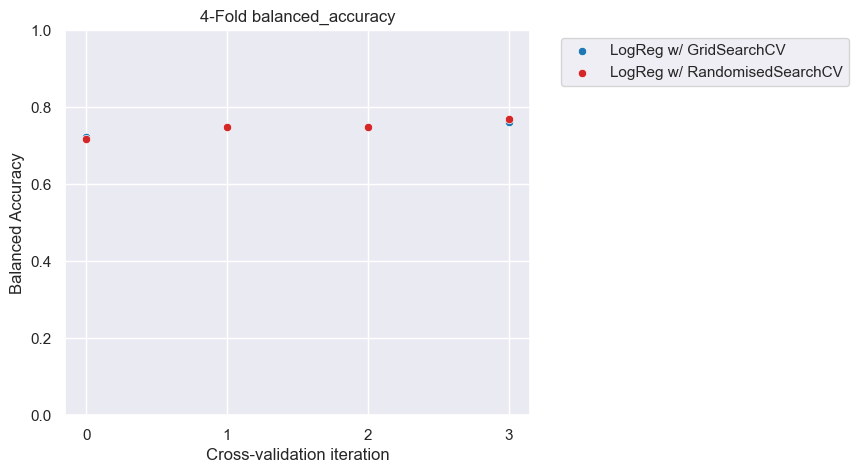

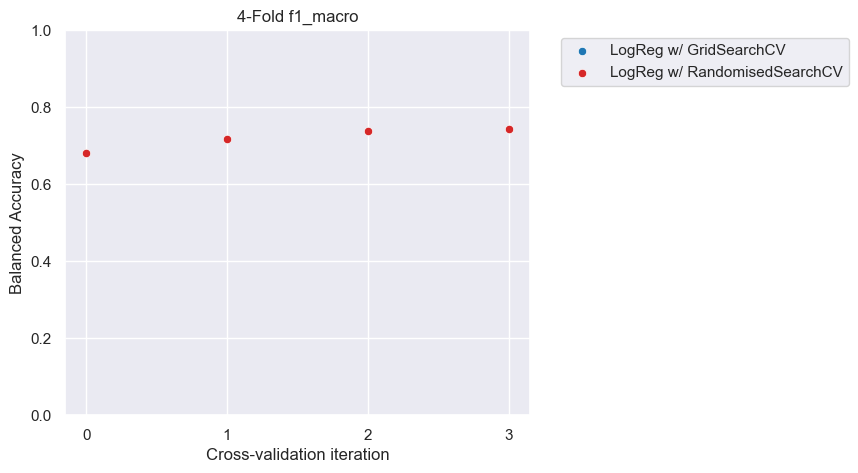

In [16]:
# plotting results from cv-folds for gridsearch and randomisedsearch logistic regression models
fold_results = (log_gridsearch_cv_score, log_randomsearch_cv_score)
label_names = ('LogReg w/ GridSearchCV', 'LogReg w/ RandomisedSearchCV')
colors=('blue', 'red')
psm_log.plot_fold_comparison(metric=psm_log.metrics[0], fold_results=fold_results, label_names=label_names, colors=colors)
psm_log.plot_fold_comparison(metric=psm_log.metrics[1], fold_results=fold_results, label_names=label_names, colors=colors)

**Which is the better linear model (tuned w/ GridSearchCV or RandomisedSearchCV)?**

* We have further proof that there is little separating the linear models tuned with GridSearchCV and RandomisedSearchCV. For all the folds, GridSearchCV performs similarly to RandomisedSearchCV for both the bal_accuracy and f1_macro metrics.

* Therefore, I will be proceeding with the RandomisedSearchCV tuned model since it is ~ 2.5x quicker.

### Tree Model - Decision Tree

#### Estimating generalisability of untuned Logistic Regression model

In [17]:
psm_tree = PlayerStatisticsModel(DecisionTreeClassifier(random_state=42), preprocessor, data, target, cv=4)
tree_cv_score_agg, tree_cv_score = psm_tree.cv_score(model_name='base_tree')
psm_tree.print_cv_results(tree_cv_score)

The mean cross-validation balanced_accuracy score is: 0.696 ± 0.670
The mean cross-validation f1_macro score is: 0.680 ± 0.669


In [18]:
# compare results
pd.concat([psm_log.results, psm_tree.results])

,balanced_accuracy_mean,f1_macro_mean,balanced_accuracy_std,f1_macro_std
base_log_reg,0.709813,0.718184,0.014054,0.011188
gridsearch_log_reg,0.745825,0.719844,0.014079,0.024144
randomsearch_log_reg,0.746206,0.720200,0.018487,0.023831
base_tree,0.664072,0.663095,0.038782,0.034652


* We observe the Tree has significantly worse performance in both balanced_accuracy and in f1_macro compared to all linear models. Perhaps the data is linearly separable, or the model is significantly overfitting. We need to make it simpler.

* There are a few options we can take. Mainly, specifying a `max_depth` that controls the complexity of the tree (i.e. underfitting/overfitting). Specifying `min_samples_split`, `max_leaf_nodes`, and `min_samples_leaf` enables an asymmetric tree.

#### Estimating generalisability of tuned Tree model varying Max Depth

In [19]:
param_grid = {"model__max_depth": np.arange(2, 16, 1)}

tree_gridsearch_cv_score_agg, tree_gridsearch_cv_score, tree_gridsearch_model = psm_tree.grid_search_cv_score(param_grid=param_grid, model_name='gridsearch_tree')

Fitting 5 folds for each of 14 candidates, totalling 70 fits
Fitting 5 folds for each of 14 candidates, totalling 70 fits
Fitting 5 folds for each of 14 candidates, totalling 70 fits
Fitting 5 folds for each of 14 candidates, totalling 70 fits
Fitting 5 folds for each of 14 candidates, totalling 70 fits
Fitting 5 folds for each of 14 candidates, totalling 70 fits
Fitting 5 folds for each of 14 candidates, totalling 70 fits
Fitting 5 folds for each of 14 candidates, totalling 70 fits


In [20]:
psm_tree.print_cv_results(tree_gridsearch_cv_score_agg)

The mean cross-validation balanced_accuracy score is: 0.654 ± 0.029
The mean cross-validation f1_macro score is: 0.662 ± 0.030


In [21]:
# optimal max_depth
[value for param, value in tree_gridsearch_model.get_params().items() if param == 'model__max_depth']

[8]

* We observe there is a significant improvement in the model after making it simpler. However, it still underperforms relative to the linear models. Can we further improve performance by adjusting other hyperparameters to allow the tree to be asynmmetric?

#### Estimating generalisability of tuned Tree model with GridSearchCV

In [22]:
param_grid = {"model__max_depth": [9],
                "model__min_samples_split": [2, 5, 10],
                "model__min_samples_leaf": [1, 2, 4],
                "model__max_leaf_nodes": [None, 10, 20, 50]}

tree_all_gridsearch_cv_score_agg, tree_all_gridsearch_cv_score, tree_all_gridsearch_model = psm_tree.grid_search_cv_score(param_grid=param_grid, model_name='gridsearch_tree_all')

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits


In [23]:
psm_tree.print_cv_results(tree_all_gridsearch_cv_score_agg)

The mean cross-validation balanced_accuracy score is: 0.655 ± 0.028
The mean cross-validation f1_macro score is: 0.661 ± 0.031


In [24]:
# compare results
pd.concat([psm_log.results, psm_tree.results])

,balanced_accuracy_mean,f1_macro_mean,balanced_accuracy_std,f1_macro_std
base_log_reg,0.709813,0.718184,0.014054,0.011188
gridsearch_log_reg,0.745825,0.719844,0.014079,0.024144
randomsearch_log_reg,0.746206,0.720200,0.018487,0.023831
base_tree,0.664072,0.663095,0.038782,0.034652
gridsearch_tree,0.654195,0.661804,0.029141,0.029991
gridsearch_tree_all,0.654940,0.661476,0.028358,0.030781


* We observe a slight improvement in both `balanced_accuracy` and `f1_macro` after allowing for the creation of an asymmetric tree. However, the model still performs poorly compared to the linear models.

* We can further compare the folds between the best linear model (logistic regression with randomsearch) and best tree (asymmetric decision tree).

### Comparison of folds between best Logistic Regression & Decision Tree models

So far, is the best Logistic Regression Model (LogReg w/ RandomisedSearchCV) or best Tree Model (Asymmetric Tuned Tree) better?

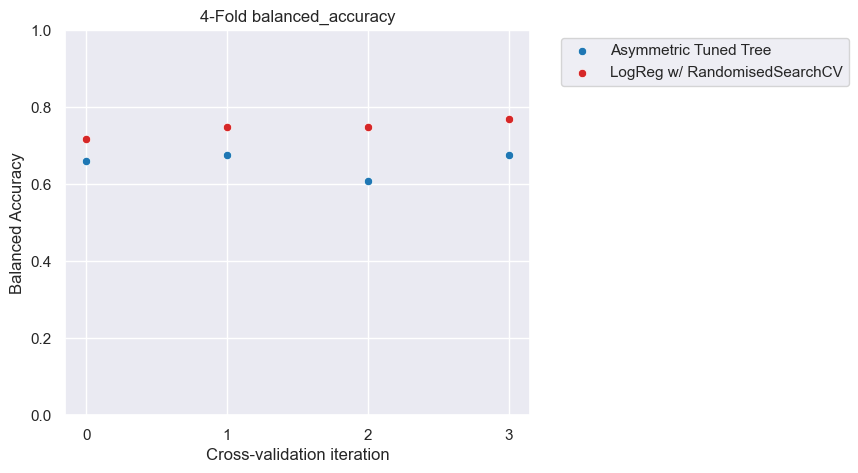

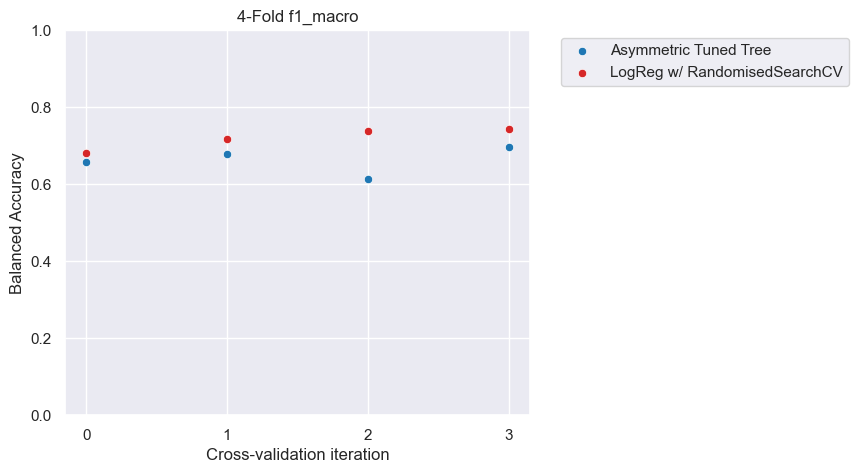

In [25]:
# plotting results from cv-folds for gridsearch and randomisedsearch logistic regression models
fold_results = (tree_all_gridsearch_cv_score, log_randomsearch_cv_score)
label_names = ('Asymmetric Tuned Tree', 'LogReg w/ RandomisedSearchCV')
colors=('blue', 'red')
psm_tree.plot_fold_comparison(metric=psm_tree.metrics[0], fold_results=fold_results, label_names=label_names, colors=colors)
psm_tree.plot_fold_comparison(metric=psm_tree.metrics[1], fold_results=fold_results, label_names=label_names, colors=colors)

* Emphatically, the best model is still logistic regression tuned with randomsearch as all 4 folds perform better in both the `balanced_accuracy` and `f1_macro` metrics.

### Ensemble Models - Random Forest

#### Estimating generalisability of untuned Random Forest

In [ ]:
psm_rf = PlayerStatisticsModel(RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1), preprocessor, data, target, cv=4)
rf_cv_score_agg, rf_cv_score = psm_rf.cv_score(model_name='base_rf')
psm_rf.print_cv_results(rf_cv_score_agg)

The mean cross-validation balanced_accuracy score is: 0.715 ± 0.018
The mean cross-validation f1_macro score is: 0.720 ± 0.016


* Even after hyperparameter tuning, the default Random Forest appeared to perform best. Furthermore, Random Forests are highly computational inefficient. Might Histogram-Based Gradient Boosting (more efficient on larger datasets) perform better?

In [40]:
pd.concat([psm_log.results, psm_tree.results, psm_rf.results])

,balanced_accuracy_mean,f1_macro_mean,balanced_accuracy_std,f1_macro_std
base_log_reg,0.709813,0.718184,0.014054,0.011188
gridsearch_log_reg,0.745825,0.719844,0.014079,0.024144
randomsearch_log_reg,0.746206,0.720200,0.018487,0.023831
base_tree,0.664072,0.663095,0.038782,0.034652
gridsearch_tree,0.654195,0.661804,0.029141,0.029991
gridsearch_tree_all,0.654940,0.661476,0.028358,0.030781
base_rf,0.714730,0.719525,0.018070,0.016211
gridsearch_rf,0.714730,0.719525,0.018070,0.016211
randomsearch_rf,0.711230,0.716152,0.018990,0.017241


### Ensemble Models - Histogram Gradient Boosting

In [ ]:
psm_hbdc = PlayerStatisticsModel(HistGradientBoostingClassifier(max_iter=1000, early_stopping=True, random_state=42, class_weight='balanced'), preprocessor, data, target, cv=4)
hbdc_cv_score_agg, hbdc_cv_score = psm_hbdc.cv_score(model_name='base_hbdc')
psm_hbdc.print_cv_results(hbdc_cv_score_agg)

The mean cross-validation balanced_accuracy score is: 0.719 ± 0.025
The mean cross-validation f1_macro score is: 0.711 ± 0.021


#### Estimating generalisability of tuned HBDC model with GridSearchCV

In [ ]:
param_grid = {
    "model__max_depth": [3, 5, 8],
    "model__max_leaf_nodes": [15, 31],
    "model__learning_rate": [0.05, 0.01, 0.1, 0.2],
    "model__class_weight": ['balanced'],
    "model__early_stopping": [True]
}

hbdc_gridsearch_cv_score_agg, hbdc_gridsearch_cv_score, hbdc_gridsearch_model = psm_hbdc.grid_search_cv_score(param_grid=param_grid, model_name='gridsearch_hbdc')

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits


In [74]:
psm_hbdc.print_cv_results(hbdc_gridsearch_cv_score_agg)

The mean cross-validation balanced_accuracy score is: 0.739 ± 0.019
The mean cross-validation f1_macro score is: 0.722 ± 0.020


In [76]:
pd.concat([psm_log.results, psm_tree.results, psm_rf.results, psm_hbdc.results])

,balanced_accuracy_mean,f1_macro_mean,balanced_accuracy_std,f1_macro_std
base_log_reg,0.709813,0.718184,0.014054,0.011188
gridsearch_log_reg,0.745825,0.719844,0.014079,0.024144
randomsearch_log_reg,0.746206,0.720200,0.018487,0.023831
base_tree,0.664072,0.663095,0.038782,0.034652
gridsearch_tree,0.654195,0.661804,0.029141,0.029991
gridsearch_tree_all,0.654940,0.661476,0.028358,0.030781
base_rf,0.714730,0.719525,0.018070,0.016211
gridsearch_rf,0.714730,0.719525,0.018070,0.016211
randomsearch_rf,0.711230,0.716152,0.018990,0.017241
base_rf,0.719291,0.710596,0.025384,0.021447


* While we observe a 2% increase in balanced accuracy and 1% increase in f1_macro via gridserch, the Histogram Gradient Boosting model still performs worse compared to the Random Search Logistic Regression model.

### SVM - Non-linear Kernel

In [10]:
psm_svm = PlayerStatisticsModel(SVC(random_state=42), preprocessor, data, target, cv=4)
svm_cv_score_agg, svm_cv_score = psm_svm.cv_score(model_name='linearsvc')
psm_svm.print_cv_results(svm_cv_score_agg)

The mean cross-validation balanced_accuracy score is: 0.717 ± 0.011
The mean cross-validation f1_macro score is: 0.724 ± 0.009


In [11]:
param_grid = {
        "model__kernel": ["rbf"],
        "model__C": [0.1, 1, 10, 100],
        "model__gamma": ["scale", "auto", 0.01, 0.001],
        "model__class_weight": ["balanced"],
        "model__probability": [True]      # necessary for prediction probabilities in-app
    }

svm_gridsearch_cv_score_agg, svm_gridsearch_cv_score, svm_gridsearch_model = psm_svm.grid_search_cv_score(param_grid=param_grid, model_name='gridsearch_svm')

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits


In [20]:
psm_svm.print_cv_results(svm_gridsearch_cv_score_agg)

The mean cross-validation balanced_accuracy score is: 0.768 ± 0.023
The mean cross-validation f1_macro score is: 0.736 ± 0.034


In [21]:
psm_svm.get_best_tuned_params(svm_gridsearch_model, param_grid)

{'model__C': 10,
 'model__class_weight': 'balanced',
 'model__gamma': 'scale',
 'model__kernel': 'rbf',
 'model__probability': True}

### Final model results comparison

In [128]:
pd.concat([psm_log.results, psm_tree.results, psm_rf.results, psm_hbdc.results, psm_svm.results]).sort_values(by=['balanced_accuracy_mean', 'f1_macro_mean'], ascending=False)

,balanced_accuracy_mean,f1_macro_mean,balanced_accuracy_std,f1_macro_std
gridsearch_svm,0.767643,0.735599,0.023013,0.033580
randomsearch_log_reg,0.746206,0.720200,0.018487,0.023831
gridsearch_log_reg,0.745825,0.719844,0.014079,0.024144
gridsearch_hbdc,0.739152,0.721641,0.018583,0.020372
randomsearch_hbdc,0.738111,0.719161,0.022834,0.022385
base_rf,0.719291,0.710596,0.025384,0.021447
linearsvc,0.716527,0.723739,0.010781,0.009389
base_rf,0.714730,0.719525,0.018070,0.016211
gridsearch_rf,0.714730,0.719525,0.018070,0.016211
randomsearch_rf,0.711230,0.716152,0.018990,0.017241


Since the **SVM model peformed best** on both the balanced accuracy and f1_macro metrics, we will seralise this model to use in the streamlit app. 

## (5) Serialise Best Performing Model

In [22]:
# Accuracy
y_pred = svm_gridsearch_model.predict(X_test)
y_pred_inverse = le.inverse_transform(y_pred)
accuracy = accuracy_score(y_test, y_pred_inverse)
print('Accuracy:', accuracy)

Accuracy: 0.7781109445277361


In [25]:
y_pred_inverse

array(['G', 'F', 'C', 'G', 'G', 'C', 'F', 'F', 'F', 'G', 'C', 'G', 'C',
       'F', 'G', 'C', 'G', 'C', 'C', 'C', 'G', 'F', 'C', 'G', 'G', 'G',
       'G', 'G', 'C', 'C', 'F', 'G', 'C', 'G', 'G', 'F', 'G', 'F', 'F',
       'C', 'G', 'F', 'F', 'C', 'G', 'F', 'G', 'G', 'F', 'G', 'G', 'C',
       'G', 'G', 'G', 'G', 'C', 'F', 'F', 'G', 'G', 'C', 'G', 'C', 'F',
       'G', 'F', 'F', 'G', 'G', 'G', 'F', 'G', 'C', 'F', 'G', 'G', 'F',
       'G', 'F', 'G', 'G', 'F', 'F', 'F', 'G', 'G', 'G', 'G', 'G', 'G',
       'G', 'C', 'C', 'G', 'F', 'C', 'G', 'F', 'C', 'G', 'C', 'F', 'G',
       'C', 'F', 'G', 'F', 'F', 'G', 'F', 'F', 'F', 'G', 'G', 'C', 'F',
       'G', 'C', 'G', 'G', 'G', 'C', 'G', 'G', 'G', 'G', 'G', 'C', 'G',
       'F', 'F', 'F', 'F', 'F', 'F', 'F', 'C', 'F', 'C', 'G', 'G', 'G',
       'G', 'G', 'G', 'G', 'F', 'G', 'F', 'F', 'F', 'F', 'G', 'F', 'G',
       'G', 'F', 'F', 'C', 'G', 'G', 'F', 'G', 'C', 'F', 'G', 'G', 'C',
       'G', 'G', 'F', 'C', 'C', 'C', 'F', 'G', 'G', 'G', 'G', 'F

### Best model from CV

Apply test data to the best performing model according to CV

### Retrain model on full dataset

Finally, I will retrain the model on the full dataset (training & validation sets) to help the model learn from as much data as possible.

In [ ]:
# Export model
#pickle.dump(svm_gridsearch_model, open(os.path.join("models", "stats_model.sav"), "wb"))
#pickle.dump(le, open(os.path.join("models", "stats_encoder.sav"), "wb"))

# Making predictions

In [40]:
def load_model(model):
    return pickle.load(open(model, 'rb'))

stats_predictor = load_model(os.path.join("models", "stats_model.sav"))
stats_le = load_model(os.path.join("models", "stats_encoder.sav"))

# Example inputs
input_features = (np.array([[20, 10, 10, 1, 1, 31, 2000]]))
stats_predictor.predict(input_features)
predicted_pos = stats_le.inverse_transform(stats_predictor.predict(input_features))[0][0]   # obtain prediction using models
print(predicted_pos)

predicted_proba = stats_predictor.predict_proba(input_features).flatten()
print(predicted_proba)
all_positions = stats_le.inverse_transform([0, 1, 2])
{pos: prob for pos, prob in zip(all_positions, predicted_proba)}

F
[0.2524626  0.64161885 0.10591854]


/Users/danielliu/anaconda3/envs/positionn/lib/python3.12/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/danielliu/anaconda3/envs/positionn/lib/python3.12/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/danielliu/anaconda3/envs/positionn/lib/python3.12/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


{'C': 0.2524626040626041, 'F': 0.6416188533688536, 'G': 0.10591854256854256}

# Testing Player Similiarity Model

The model that finds the most similar active NBA player is in `similar_player_statistics.py`

### Create new dataset that contains all active player statistics

In [ ]:
player_statistics_processed.tail()

,Unnamed: 0,player,pos,pts,ast,trb,stl,blk,age,year
20791,20791,Cody Zeller,F,10.31,1.60,6.53,1.00,0.94,24.0,2017.0
20792,20792,Tyler Zeller,C,3.49,0.82,2.43,0.14,0.41,27.0,2017.0
20793,20793,Stephen Zimmerman,C,1.21,0.21,1.84,0.11,0.26,20.0,2017.0
20794,20794,Paul Zipser,F,5.45,0.82,2.84,0.34,0.36,22.0,2017.0
20795,20795,Ivica Zubac,C,7.47,0.79,4.18,0.37,0.87,19.0,2017.0


In [ ]:
active_players_processed.tail()

,playerid,fname,lname,position,height,weight,BMI
543,201152,Thaddeus,Young,F,203.20,106.594207,25.815836
544,1629027,Trae,Young,G,185.42,74.389149,21.636970
545,1630209,Omer,Yurtseven,C,210.82,124.737902,28.065631
546,203469,Cody,Zeller,F,210.82,108.862169,24.493642
547,1627826,Ivica,Zubac,C,213.36,108.862169,23.913931


In [ ]:
# Concatenate first and last names in active players
active_players_concat = active_players_processed.copy()
active_players_concat['fullname'] = active_players_processed['fname'] + ' ' + active_players_processed['lname']


In [ ]:
active_players_concat.head()

,playerid,fname,lname,position,height,weight,BMI,fullname
0,1630173,Precious,Achiuwa,F,203.20,102.058283,24.717290,Precious Achiuwa
1,203500,Steven,Adams,C,210.82,120.201978,27.045063,Steven Adams
2,1628389,Bam,Adebayo,C,205.74,115.666054,27.325521,Bam Adebayo
3,1630534,Ochai,Agbaji,G,195.58,97.522360,25.495018,Ochai Agbaji
4,1630583,Santi,Aldama,F,213.36,97.522360,21.422897,Santi Aldama


In [ ]:
# Attach on player year-by-year statistics of active players:
active_player_statistics = pd.merge(active_players_concat, player_statistics_processed, left_on = 'fullname', right_on = 'player', how = 'inner')

active_player_statistics.head()

,playerid,fname,lname,position,height,weight,BMI,fullname,Unnamed: 0,player,pos,pts,ast,trb,stl,blk,age,year
0,203500,Steven,Adams,C,210.82,120.201978,27.045063,Steven Adams,18364,Steven Adams,C,3.27,0.53,4.10,0.49,0.70,20.0,2014.0
1,203500,Steven,Adams,C,210.82,120.201978,27.045063,Steven Adams,18974,Steven Adams,C,7.67,0.94,7.47,0.54,1.23,21.0,2015.0
2,203500,Steven,Adams,C,210.82,120.201978,27.045063,Steven Adams,19625,Steven Adams,C,7.95,0.78,6.66,0.52,1.11,22.0,2016.0
3,203500,Steven,Adams,C,210.82,120.201978,27.045063,Steven Adams,20205,Steven Adams,C,11.31,1.08,7.69,1.10,0.98,23.0,2017.0
4,203937,Kyle,Anderson,F,205.74,104.326245,24.646548,Kyle Anderson,18991,Kyle Anderson,F,2.24,0.85,2.18,0.45,0.21,21.0,2015.0


In [ ]:
# Export results
active_player_statistics.to_csv(os.path.join("data", "active_player_stats.csv"))

### Test similarity model

In [ ]:
# Make a prediction with player similarity model
from similar_player_stats import SimilarPlayerStats
active_player_statistics = pd.read_csv(os.path.join("data", "active_player_stats.csv"))
similar_player_stats = SimilarPlayerStats(active_player_statistics)
print(similar_player_stats.predict_similar_player(20, 10, 5, 1, 1, 'G'))

Unnamed: 0.1               810
playerid                202322
fname                     John
lname                     Wall
position                     G
height                   190.5
weight               95.254398
BMI                  26.247931
fullname             John Wall
Unnamed: 0               18325
player               John Wall
pos                          G
pts                      18.49
ast                       7.61
trb                        4.0
stl                       1.33
blk                       0.76
age                       22.0
year                    2013.0
cosine_similarity     0.976945
Name: 810, dtype: object


/Users/danielliu/anaconda3/envs/positionn/lib/python3.12/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/danielliu/Desktop/Dev/positionn/similar_player_stats.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  active_pos_players['cosine_similarity'] = np.squeeze(cosine_res)


In [ ]:
# Export model
#pickle.dump(similar_player_stats, open(os.path.join("models", "similar_player_stats.pkl"), "wb"))